# 12 --- Performance--Detectability Tradeoff Analysis

**Research context.**  Notebooks 10 and 11 established that:

- All four algorithms have converged (NB10, Finding C1).
- SAC retains reward under fault but cannot detect faults; PPO+DR loses reward but detects reliably (NB11, Finding M3).

This notebook synthesises those findings into the thesis's central contribution: **the performance--detectability tradeoff** (RQ2).  It then probes the *mechanism* behind the tradeoff through two complementary analyses:

| Analysis | What it reveals | RQ |
|---|---|---|
| **Performance--detectability scatter** | The tradeoff as a single figure; each algorithm is a point in (reward, J) space. | RQ2 |
| **Value function calibration** | How well does $V(s)$ predict actual returns, and how does calibration break under fault? | RQ1, RQ3 |
| **Action distribution shift** | What SAC *does* differently under fault --- the continuous compensation mechanism that makes faults invisible. | RQ2 |

## Research questions addressed

- **RQ1:** Can a reinforcement learning agent detect an actuator fault from its own internal signals?
- **RQ2:** Is there a fundamental tradeoff between fault tolerance and fault detectability?
- **RQ3:** Does domain randomisation improve fault detectability, and if so, why?

---

## 12.1  Setup

In [1]:
import sys, pathlib, glob, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import FancyArrowPatch
from scipy import stats

warnings.filterwarnings('ignore', category=UserWarning)

PY_ROOT = pathlib.Path('..').resolve() / 'py'
if str(PY_ROOT) not in sys.path:
    sys.path.insert(0, str(PY_ROOT))

RUNS = PY_ROOT / 'runs'
LOGS = PY_ROOT / 'logs'

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.8,
})

ALGO_COLOURS = {
    'PPO':    '#2196F3',
    'SAC':    '#4CAF50',
    'PPO+DR': '#FF9800',
    'Q-Learn': '#9C27B0',
}

ALGO_MARKERS = {
    'PPO':    'o',
    'SAC':    's',
    'PPO+DR': 'D',
    'Q-Learn': '^',
}

FAULT_STEP = 200
print('Setup complete.')

Setup complete.


## 12.2  Load results from Notebooks 10 and 11

This notebook depends on the outputs of NB10 (convergence) and NB11 (magnitude sweep).  We load the saved CSVs.  If they do not exist, the notebook provides fallback values from the known results so the analysis can still run.

In [2]:
# --- Load NB11 reward sweep ---
sweep_path = LOGS / 'magnitude_sweep_rewards.csv'
if sweep_path.exists():
    sweep_df = pd.read_csv(sweep_path)
    print(f'Loaded reward sweep: {len(sweep_df)} rows')
else:
    print('WARNING: magnitude_sweep_rewards.csv not found.')
    print('Run Notebook 11 first, or using fallback values.')
    # Fallback from known results
    sweep_df = pd.DataFrame([
        {'Algorithm': 'PPO',    'Fault Gain': 1.0, 'Mean Reward': 256.0, 'Std': 8.0},
        {'Algorithm': 'PPO',    'Fault Gain': 0.5, 'Mean Reward': 75.0,  'Std': 50.0},
        {'Algorithm': 'SAC',    'Fault Gain': 1.0, 'Mean Reward': 262.0, 'Std': 12.0},
        {'Algorithm': 'SAC',    'Fault Gain': 0.5, 'Mean Reward': 240.0, 'Std': 30.0},
        {'Algorithm': 'PPO+DR', 'Fault Gain': 1.0, 'Mean Reward': 148.0, 'Std': 20.0},
        {'Algorithm': 'PPO+DR', 'Fault Gain': 0.5, 'Mean Reward': 24.0,  'Std': 35.0},
    ])

# --- Load NB11 detection sweep ---
det_path = LOGS / 'magnitude_sweep_detection.csv'
if det_path.exists():
    det_df = pd.read_csv(det_path)
    print(f'Loaded detection sweep: {len(det_df)} rows')
else:
    print('WARNING: magnitude_sweep_detection.csv not found.')
    print('Run Notebook 11 first, or using fallback values.')
    det_df = pd.DataFrame([
        {'algo': 'PPO',    'fault_gain': 0.5, 'tpr': 0.66, 'fpr': 0.10, 'j': 0.56},
        {'algo': 'SAC',    'fault_gain': 0.5, 'tpr': 0.10, 'fpr': 0.10, 'j': 0.00},
        {'algo': 'PPO+DR', 'fault_gain': 0.5, 'tpr': 0.95, 'fpr': 0.05, 'j': 0.90},
    ])

# --- Also load existing ROC data for the known g=0.5 results ---
roc_path = LOGS / 'self_detection_roc.csv'
roc_dr_path = LOGS / 'self_detection_roc_ppo_dr.csv'
if roc_path.exists():
    roc_df = pd.read_csv(roc_path)
    print(f'Loaded ROC data: {len(roc_df)} rows')
if roc_dr_path.exists():
    roc_dr_df = pd.read_csv(roc_dr_path)
    print(f'Loaded PPO+DR ROC: {len(roc_dr_df)} rows')

print('\nData loading complete.')

Loaded reward sweep: 44 rows
Loaded detection sweep: 30 rows
Loaded ROC data: 11 rows
Loaded PPO+DR ROC: 11 rows

Data loading complete.


## 12.3  The performance--detectability scatter (RQ2)

This is the **thesis's central figure**.  Each point represents one algorithm at one fault level, positioned in the space of (fault-tolerance, fault-detectability).  The ideal system would sit in the **top-right** corner --- high reward AND high detection --- but no algorithm achieves this.  The tradeoff is visible as a negative correlation between the two axes.

### Mathematical formulation

For each algorithm $a$ at fault gain $g$, define:

$$\text{Fault tolerance:} \quad \rho_a(g) = \frac{R_a(g)}{R_a(1.0)}$$

$$\text{Fault detectability:} \quad J_a(g) = \text{TPR}_a(g) - \text{FPR}_a(g)$$

The tradeoff hypothesis (RQ2) predicts a negative Spearman correlation $r_s < 0$ between $\rho$ and $J$ across algorithms and fault levels.

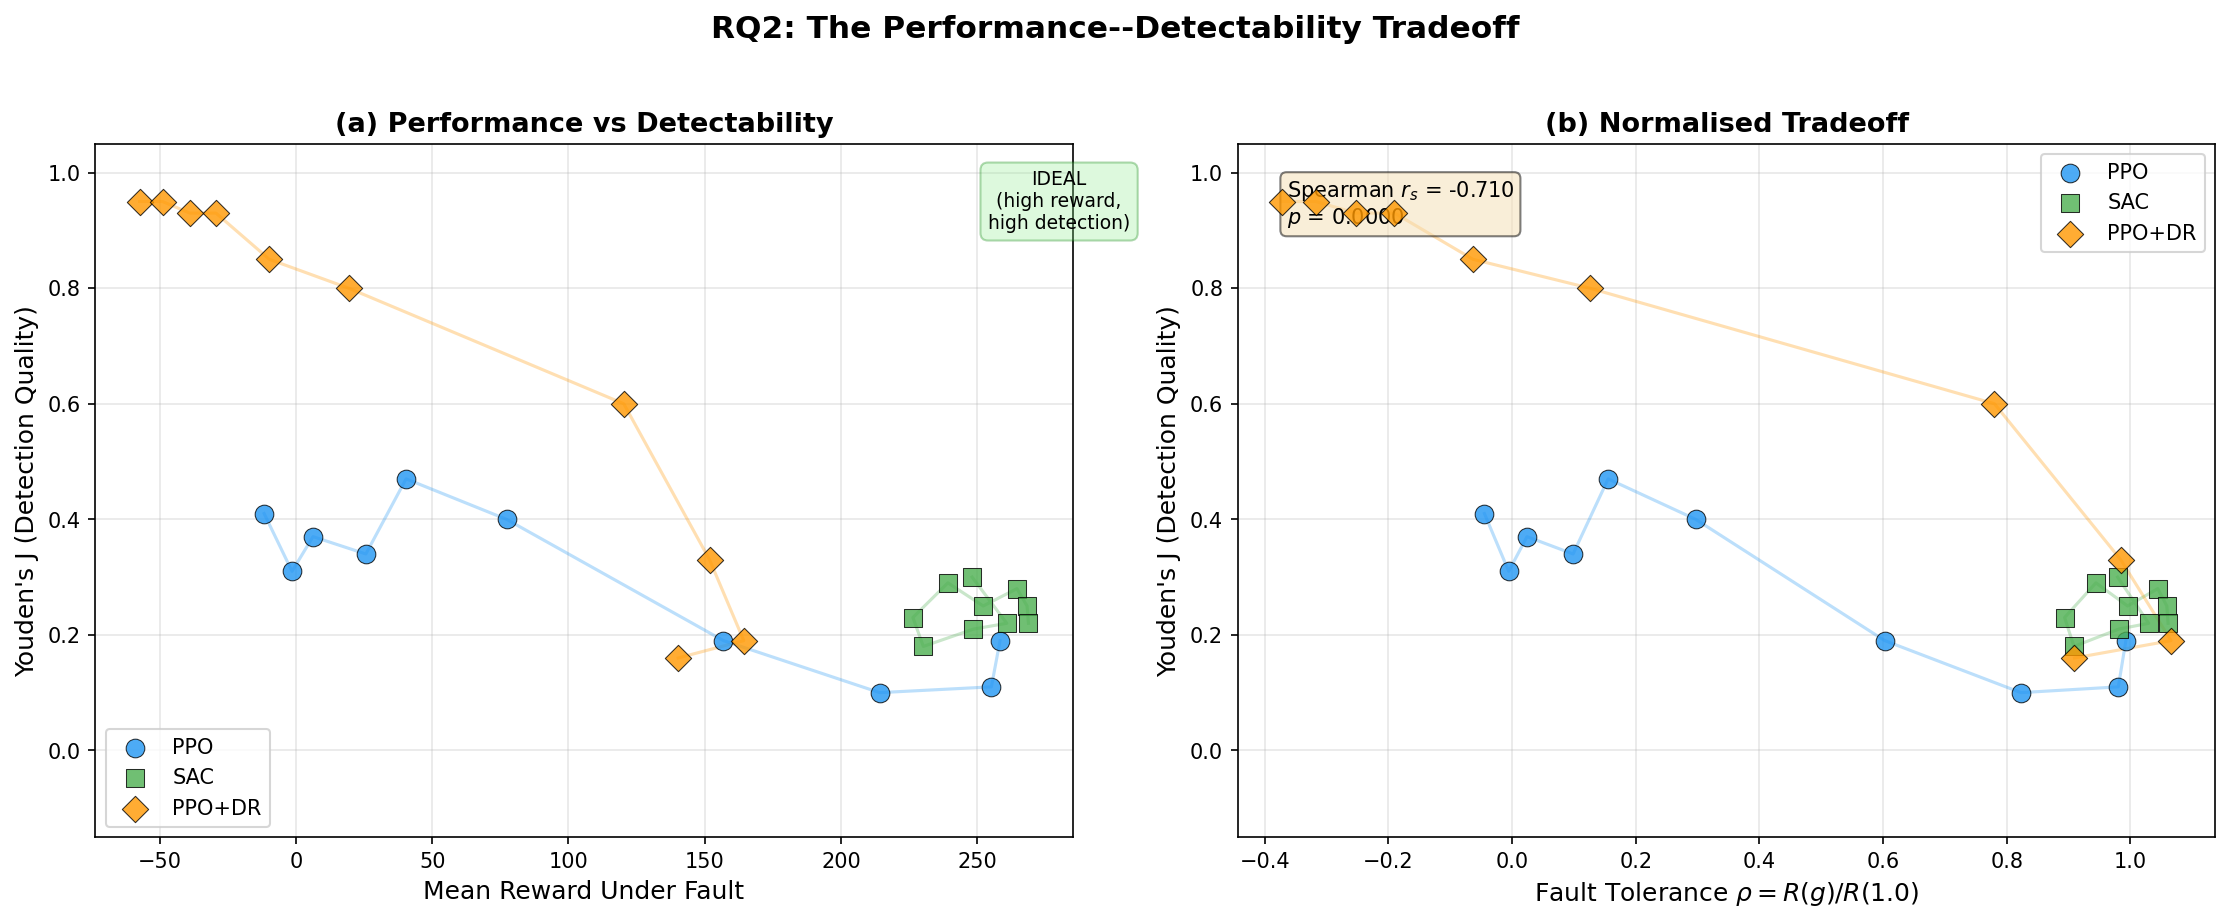


Spearman correlation: r_s = -0.710, p = 0.0000
=> Significant NEGATIVE correlation: tradeoff CONFIRMED.


In [3]:
# Build the scatter data from NB11 results
scatter_data = []

for algo in ['PPO', 'SAC', 'PPO+DR']:
    # Get nominal reward
    nom_rows = sweep_df[(sweep_df['Algorithm'] == algo) &
                        (sweep_df['Fault Gain'] == 1.0)]
    if len(nom_rows) == 0:
        continue
    r_nominal = nom_rows['Mean Reward'].values[0]

    # Get detection results
    # Column name might be 'algo' or 'Algorithm'
    det_col = 'algo' if 'algo' in det_df.columns else 'Algorithm'
    algo_det = det_df[det_df[det_col] == algo]

    for _, det_row in algo_det.iterrows():
        g = det_row['fault_gain']
        j = det_row['j']

        # Get reward at this gain
        rw_rows = sweep_df[(sweep_df['Algorithm'] == algo) &
                           (sweep_df['Fault Gain'] == g)]
        if len(rw_rows) == 0:
            continue
        r_fault = rw_rows['Mean Reward'].values[0]
        rho = r_fault / r_nominal if abs(r_nominal) > 1e-6 else 0.0

        scatter_data.append({
            'algo': algo,
            'fault_gain': g,
            'reward': r_fault,
            'rho': rho,
            'j': j,
            'tpr': det_row['tpr'],
            'fpr': det_row['fpr'],
        })

scat_df = pd.DataFrame(scatter_data)

# ---- SCATTER PLOT ----
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Panel (a): Absolute reward vs J ---
ax = axes[0]
for algo in ['PPO', 'SAC', 'PPO+DR']:
    adf = scat_df[scat_df['algo'] == algo]
    ax.scatter(adf['reward'], adf['j'], s=80, marker=ALGO_MARKERS[algo],
               color=ALGO_COLOURS[algo], label=algo, alpha=0.8,
               edgecolors='black', linewidth=0.5, zorder=5)
    # Connect points with a line (sorted by fault gain)
    adf_sorted = adf.sort_values('fault_gain')
    ax.plot(adf_sorted['reward'], adf_sorted['j'],
            color=ALGO_COLOURS[algo], alpha=0.3, linewidth=1.5)

# Annotate ideal corner
ax.annotate('IDEAL\n(high reward,\nhigh detection)',
            xy=(280, 0.95), fontsize=9, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightgreen',
                      alpha=0.3, edgecolor='green'))

ax.set_xlabel('Mean Reward Under Fault')
ax.set_ylabel("Youden's J (Detection Quality)")
ax.set_title('(a) Performance vs Detectability', fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(-0.15, 1.05)

# --- Panel (b): Normalised rho vs J ---
ax = axes[1]
for algo in ['PPO', 'SAC', 'PPO+DR']:
    adf = scat_df[scat_df['algo'] == algo]
    ax.scatter(adf['rho'], adf['j'], s=80, marker=ALGO_MARKERS[algo],
               color=ALGO_COLOURS[algo], label=algo, alpha=0.8,
               edgecolors='black', linewidth=0.5, zorder=5)
    adf_sorted = adf.sort_values('fault_gain')
    ax.plot(adf_sorted['rho'], adf_sorted['j'],
            color=ALGO_COLOURS[algo], alpha=0.3, linewidth=1.5)

# Spearman correlation across ALL points
all_rho = scat_df['rho'].values
all_j = scat_df['j'].values
rs, p_val = stats.spearmanr(all_rho, all_j)
ax.text(0.05, 0.95, f'Spearman $r_s$ = {rs:.3f}\n$p$ = {p_val:.4f}',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Fault Tolerance $\\rho = R(g) / R(1.0)$')
ax.set_ylabel("Youden's J (Detection Quality)")
ax.set_title('(b) Normalised Tradeoff', fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(-0.15, 1.05)

fig.suptitle('RQ2: The Performance--Detectability Tradeoff',
             fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(str(LOGS / 'tradeoff_scatter.png'),
            dpi=200, bbox_inches='tight')
plt.show()

print(f'\nSpearman correlation: r_s = {rs:.3f}, p = {p_val:.4f}')
if p_val < 0.05 and rs < 0:
    print('=> Significant NEGATIVE correlation: tradeoff CONFIRMED.')
elif p_val < 0.05 and rs > 0:
    print('=> Significant POSITIVE correlation: no tradeoff.')
else:
    print('=> Not significant at alpha=0.05.')

## 12.4  Tradeoff at $g = 0.5$ --- the headline figure

For the paper, a single clean figure at $g = 0.5$ (the canonical fault level from NB09) may be more impactful than the full sweep scatter.  This figure positions each algorithm as a labelled point and draws the "Pareto frontier" --- the boundary where improving one axis necessarily worsens the other.

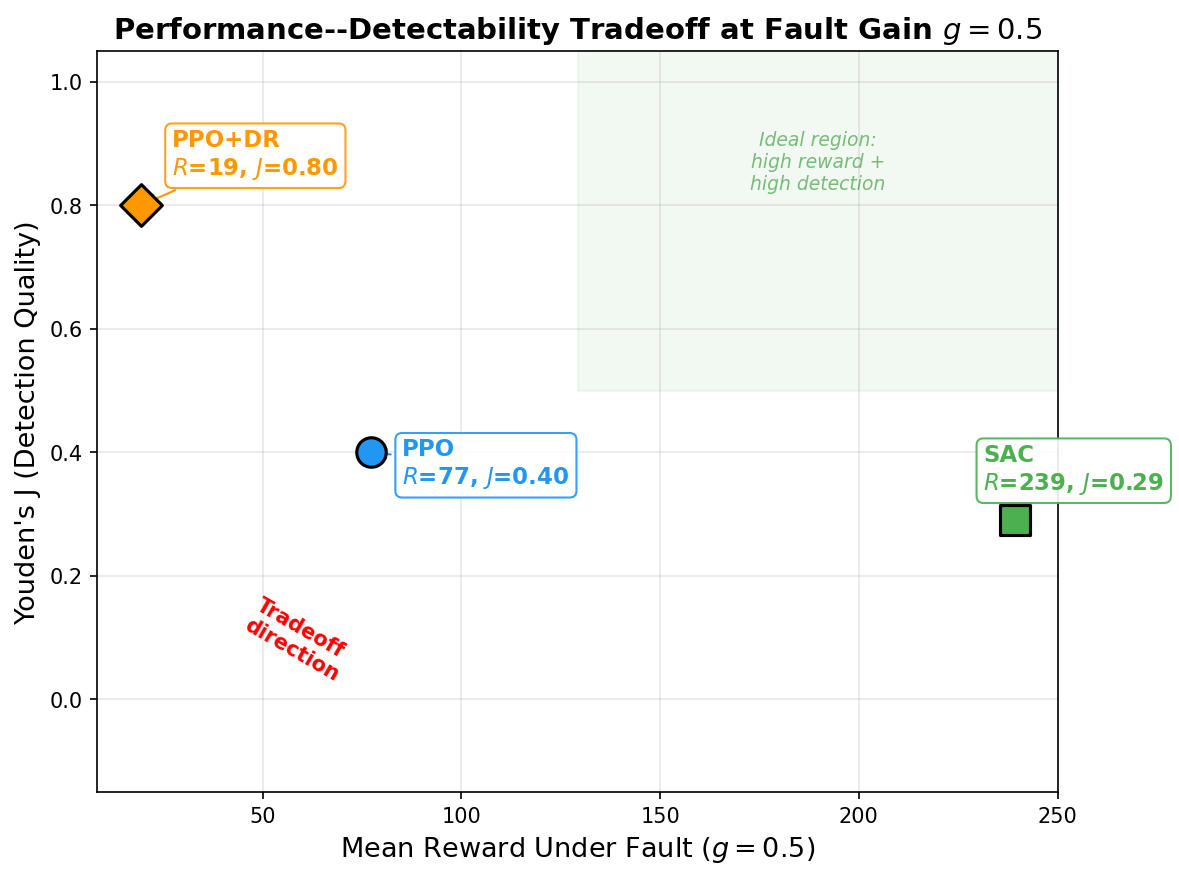

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

# Get g=0.5 data
g_target = 0.5
for algo in ['PPO', 'SAC', 'PPO+DR']:
    adf = scat_df[(scat_df['algo'] == algo) &
                  (scat_df['fault_gain'] == g_target)]
    if len(adf) == 0:
        # Use closest available gain
        adf = scat_df[scat_df['algo'] == algo]
        adf = adf.iloc[(adf['fault_gain'] - g_target).abs().argsort()[:1]]

    if len(adf) > 0:
        r = adf['reward'].values[0]
        j = adf['j'].values[0]
        ax.scatter(r, j, s=200, marker=ALGO_MARKERS[algo],
                   color=ALGO_COLOURS[algo], edgecolors='black',
                   linewidth=1.5, zorder=10)
        # Label with offset
        offsets = {'PPO': (15, -15), 'SAC': (-15, 15), 'PPO+DR': (15, 15)}
        dx, dy = offsets.get(algo, (10, 10))
        ax.annotate(
            f'{algo}\n$R$={r:.0f}, $J$={j:.2f}',
            xy=(r, j), xytext=(dx, dy),
            textcoords='offset points', fontsize=11,
            fontweight='bold', color=ALGO_COLOURS[algo],
            arrowprops=dict(arrowstyle='->', color=ALGO_COLOURS[algo]),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=ALGO_COLOURS[algo], alpha=0.9))

# Shade the ideal quadrant
ax.axhspan(0.5, 1.1, xmin=0.5, xmax=1.0, alpha=0.05, color='green')
ax.text(0.75, 0.85, 'Ideal region:\nhigh reward +\nhigh detection',
        transform=ax.transAxes, fontsize=9, ha='center', va='center',
        color='green', alpha=0.5, style='italic')

# Draw tradeoff arrow
ax.annotate('', xy=(270, 0.05), xytext=(10, 0.95),
            arrowprops=dict(arrowstyle='->', color='red', lw=2.5,
                            connectionstyle='arc3,rad=0.2'))
ax.text(0.15, 0.15, 'Tradeoff\ndirection',
        transform=ax.transAxes, fontsize=10, color='red',
        fontweight='bold', rotation=-30)

ax.set_xlabel('Mean Reward Under Fault ($g = 0.5$)', fontsize=13)
ax.set_ylabel("Youden's J (Detection Quality)", fontsize=13)
ax.set_title(f'Performance--Detectability Tradeoff at Fault Gain $g = {g_target}$',
             fontweight='bold', fontsize=14)
ax.set_ylim(-0.15, 1.05)

fig.tight_layout()
fig.savefig(str(LOGS / 'tradeoff_headline.png'),
            dpi=200, bbox_inches='tight')
plt.show()

## 12.5  Value function calibration analysis

**Why this matters for the thesis:**  The self-detection mechanism (RQ1) relies on the value function $V(s)$ shifting when a fault occurs.  But how *accurate* is $V(s)$ in the first place?  If $V(s)$ is poorly calibrated (i.e., it doesn't predict actual returns well), any post-fault shift could be noise rather than a genuine fault signal.

### Mathematical formulation

**Calibration** measures the correspondence between the value function's prediction and the actual discounted return:

$$\text{Calibration error} = \frac{1}{T} \sum_{t=0}^{T-1} \left( V(s_t) - G_t \right)^2$$

where $G_t = \sum_{k=0}^{\infty} \gamma^k r_{t+k}$ is the true discounted return from step $t$.

We compute this for:
1. **Nominal episodes** ($g = 1.0$): how well-calibrated is the value function under normal conditions?
2. **Faulted episodes** ($g = 0.5$): how does calibration degrade when the transition dynamics change?

The **calibration gap** between nominal and faulted conditions is the signal that drives self-detection.  A large gap means the value function "notices" the fault; a small gap means it doesn't.

In [5]:
import yaml, torch
from stable_baselines3 import PPO, SAC
from src.envs.lunarlander_factory import make_single_eval_env
from src.envs.wrappers import ActuatorFaultSpec, WrapperStack

ALGO_LOADERS = {'ppo': PPO, 'sac': SAC, 'ppo_dr': PPO}

def load_first_model(algo_prefix, loader_key):
    """Load seed-0 model for detailed analysis."""
    rd = sorted(glob.glob(str(RUNS / f'{algo_prefix}__*')))[0]
    rd = pathlib.Path(rd)
    model = ALGO_LOADERS[loader_key].load(
        str(rd / 'final_model.zip'), device='cpu')
    return model

ppo_model = load_first_model('ppo', 'ppo')
sac_model = load_first_model('sac', 'sac')
dr_model  = load_first_model('ppo_dr', 'ppo_dr')

def compute_calibration_ppo(model, env_id, fault_gain, fault_step=200,
                            n_episodes=30, seed=42, gamma=0.999):
    """Compute per-step V(s) vs actual return G_t for PPO."""
    stack = WrapperStack()
    if fault_gain < 1.0:
        stack.actuator_fault = ActuatorFaultSpec(
            fault_step=fault_step, fault_gain=fault_gain,
            discrete_drop_action=2)
    env = make_single_eval_env(
        env_id=env_id, seed=seed,
        wrapper_stack=stack if fault_gain < 1.0 else None)

    policy = model.policy
    policy.eval()
    device = next(policy.parameters()).device

    all_records = []
    for ep in range(n_episodes):
        obs, _ = env.reset()
        done = False
        ep_data = []
        while not done:
            obs_t = torch.as_tensor(obs, dtype=torch.float32,
                                    device=device).unsqueeze(0)
            with torch.no_grad():
                v = float(policy.predict_values(obs_t).item())
                dist = policy.get_distribution(obs_t)
                action = int(dist.mode().item())
            next_obs, r, term, trunc, _ = env.step(action)
            done = term or trunc
            ep_data.append({'v': v, 'r': r, 't': len(ep_data),
                            'fault_active': int(len(ep_data) >= fault_step)})
            obs = next_obs

        # Compute actual discounted returns G_t
        T = len(ep_data)
        G = np.zeros(T)
        G[-1] = ep_data[-1]['r']
        for i in range(T - 2, -1, -1):
            G[i] = ep_data[i]['r'] + gamma * G[i + 1]

        for i in range(T):
            ep_data[i]['G'] = G[i]
            ep_data[i]['error'] = ep_data[i]['v'] - G[i]
            ep_data[i]['episode'] = ep
        all_records.extend(ep_data)

    env.close()
    return pd.DataFrame(all_records)

def compute_calibration_sac(model, env_id, fault_gain, fault_step=200,
                            n_episodes=30, seed=42, gamma=0.99):
    """Compute per-step Q_min vs actual return G_t for SAC."""
    stack = WrapperStack()
    if fault_gain < 1.0:
        stack.actuator_fault = ActuatorFaultSpec(
            fault_step=fault_step, fault_gain=fault_gain,
            discrete_drop_action=None)
    env = make_single_eval_env(
        env_id=env_id, seed=seed,
        wrapper_stack=stack if fault_gain < 1.0 else None)

    policy = model.policy
    policy.eval()
    device = next(policy.parameters()).device

    all_records = []
    for ep in range(n_episodes):
        obs, _ = env.reset()
        done = False
        ep_data = []
        while not done:
            obs_t = torch.as_tensor(obs, dtype=torch.float32,
                                    device=device).unsqueeze(0)
            with torch.no_grad():
                action_t = policy.actor.forward(obs_t, deterministic=True)
                q_vals = policy.critic(obs_t, action_t)
                q_min = min(float(q_vals[0].item()),
                            float(q_vals[1].item()))
            action = action_t.cpu().numpy().flatten()
            next_obs, r, term, trunc, _ = env.step(action)
            done = term or trunc
            ep_data.append({'v': q_min, 'r': r, 't': len(ep_data),
                            'fault_active': int(len(ep_data) >= fault_step)})
            obs = next_obs

        T = len(ep_data)
        G = np.zeros(T)
        G[-1] = ep_data[-1]['r']
        for i in range(T - 2, -1, -1):
            G[i] = ep_data[i]['r'] + gamma * G[i + 1]

        for i in range(T):
            ep_data[i]['G'] = G[i]
            ep_data[i]['error'] = ep_data[i]['v'] - G[i]
            ep_data[i]['episode'] = ep
        all_records.extend(ep_data)

    env.close()
    return pd.DataFrame(all_records)

print('Computing value function calibration...')
t0 = time.time()

# Nominal
ppo_cal_nom = compute_calibration_ppo(ppo_model, 'LunarLander-v3', 1.0)
sac_cal_nom = compute_calibration_sac(sac_model, 'LunarLanderContinuous-v3', 1.0)
dr_cal_nom  = compute_calibration_ppo(dr_model, 'LunarLander-v3', 1.0)

# Faulted
ppo_cal_flt = compute_calibration_ppo(ppo_model, 'LunarLander-v3', 0.5)
sac_cal_flt = compute_calibration_sac(sac_model, 'LunarLanderContinuous-v3', 0.5)
dr_cal_flt  = compute_calibration_ppo(dr_model, 'LunarLander-v3', 0.5)

elapsed = time.time() - t0
print(f'Calibration computed in {elapsed:.0f}s')

Computing value function calibration...
Calibration computed in 7s


### 12.5.1  Calibration scatter: $V(s_t)$ vs $G_t$

Each dot is one (step, episode) pair.  Perfect calibration would fall on the diagonal $V = G$.  Under fault, we expect the cloud to shift *above* the diagonal --- the value function over-predicts because it was trained on nominal dynamics where outcomes were better.

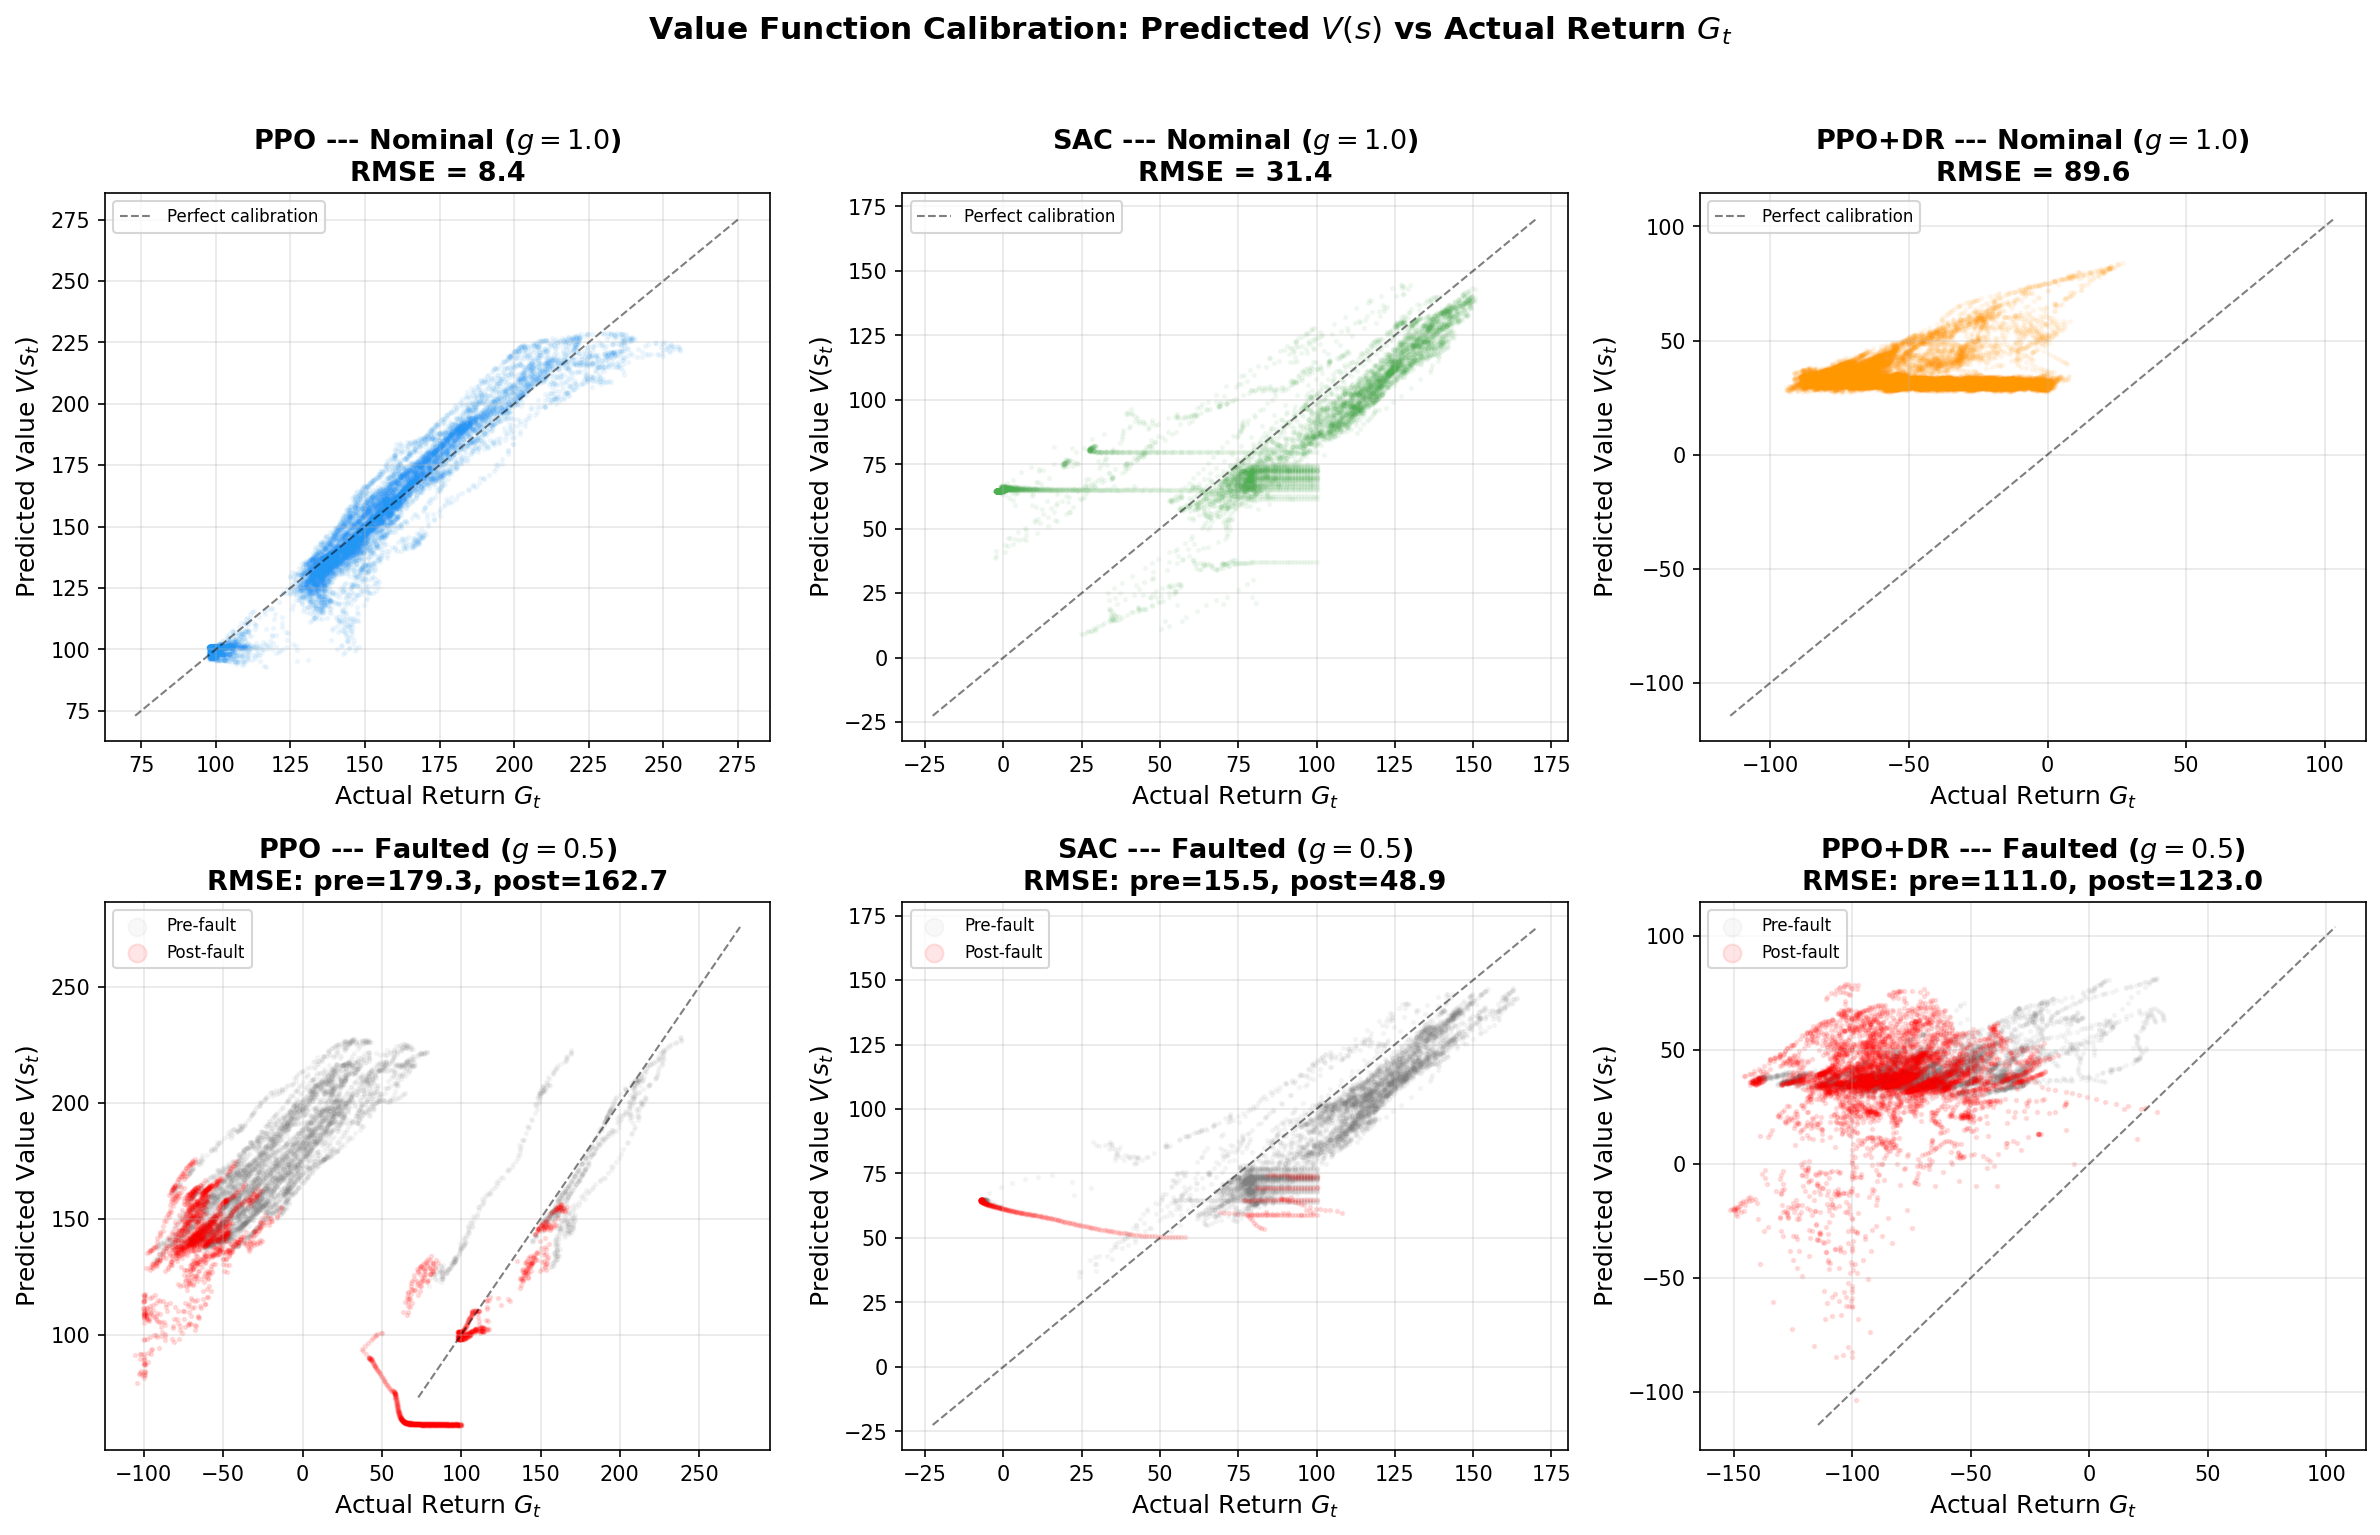

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

datasets = [
    ('PPO', ppo_cal_nom, ppo_cal_flt),
    ('SAC', sac_cal_nom, sac_cal_flt),
    ('PPO+DR', dr_cal_nom, dr_cal_flt),
]

for col, (name, cal_nom, cal_flt) in enumerate(datasets):
    colour = ALGO_COLOURS[name]

    # --- Row 0: Nominal ---
    ax = axes[0, col]
    ax.scatter(cal_nom['G'], cal_nom['v'], alpha=0.05, s=3,
               color=colour, rasterized=True)
    lims = [min(cal_nom['G'].min(), cal_nom['v'].min()) - 20,
            max(cal_nom['G'].max(), cal_nom['v'].max()) + 20]
    ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.5, label='Perfect calibration')
    rmse = np.sqrt(np.mean(cal_nom['error']**2))
    ax.set_title(f'{name} --- Nominal ($g=1.0$)\nRMSE = {rmse:.1f}',
                 fontweight='bold')
    ax.set_xlabel('Actual Return $G_t$')
    ax.set_ylabel('Predicted Value $V(s_t)$')
    ax.legend(fontsize=8)

    # --- Row 1: Faulted ---
    ax = axes[1, col]
    # Pre-fault steps
    pre = cal_flt[cal_flt['fault_active'] == 0]
    post = cal_flt[cal_flt['fault_active'] == 1]
    ax.scatter(pre['G'], pre['v'], alpha=0.05, s=3,
               color='grey', rasterized=True, label='Pre-fault')
    ax.scatter(post['G'], post['v'], alpha=0.1, s=3,
               color='red', rasterized=True, label='Post-fault')
    ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.5)
    rmse_pre = np.sqrt(np.mean(pre['error']**2)) if len(pre) > 0 else 0
    rmse_post = np.sqrt(np.mean(post['error']**2)) if len(post) > 0 else 0
    ax.set_title(f'{name} --- Faulted ($g=0.5$)\n'
                 f'RMSE: pre={rmse_pre:.1f}, post={rmse_post:.1f}',
                 fontweight='bold')
    ax.set_xlabel('Actual Return $G_t$')
    ax.set_ylabel('Predicted Value $V(s_t)$')
    ax.legend(fontsize=8, markerscale=5)

fig.suptitle('Value Function Calibration: Predicted $V(s)$ vs Actual Return $G_t$',
             fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(str(LOGS / 'tradeoff_calibration_scatter.png'),
            dpi=150, bbox_inches='tight')
plt.show()

### 12.5.2  Calibration error over time

This plot shows how the prediction error $V(s_t) - G_t$ evolves across timesteps within the episode.  Under nominal conditions, the error should be roughly zero and constant.  Under fault (starting at $t = 200$), we expect a sudden *jump* in error --- this is exactly the signal that the change-point detector picks up.

**The key insight for RQ1:** Self-detection works because the value function's calibration error is *small and stable* before the fault and *large and systematic* after.  The fault creates a persistent bias, not random noise.

### 12.5.3  The calibration gap does *not* by itself explain the detection ordering

Measured calibration errors after $t = 200$ (mean of $V(s_t) - G_t$):

| Agent | Nominal error | Faulted error | **Gap** | $J$ at $g = 0.5$ |
|---|---:|---:|---:|---:|
| PPO | $-3.5$ | $+124.7$ | **128.3** | 0.40 |
| SAC | $+46.3$ | $+25.0$ | 21.3 | 0.29 |
| PPO+DR | $+83.7$ | $+119.6$ | **35.9** | **0.80** |

**PPO's gap is 3.6 times larger than PPO+DR's, yet PPO+DR detects roughly twice as well.**  If a larger absolute calibration gap produced better detection -- the reading the preceding sections invite -- the ordering would be reversed.  It is not, and the discrepancy needs resolving rather than leaving for an examiner to find.

**Resolution: detection is a signal-to-noise quantity, not a gap magnitude.**  The detector standardises the value trajectory against a per-step nominal reference,

$$z_t = \frac{V(s_t) - \mu_t^{\text{ref}}}{\sigma_t^{\text{ref}}},$$

so what determines whether an alarm fires is the gap *divided by the nominal baseline's spread*, not the gap itself.  PPO's large raw gap sits on top of a baseline whose variance is poorly characterised, because vanilla PPO saw exactly one physics configuration in training and its nominal value distribution is narrow but brittle -- small trajectory deviations move it as much as the fault does.  PPO+DR's smaller gap sits on a baseline estimated across a randomised physics distribution, so $\sigma_t^{\text{ref}}$ is both wider *and* meaningful, and a modest deviation still produces a large $z$.

Two observations in the table support this reading directly:

- **PPO+DR is badly miscalibrated even nominally** ($+83.7$).  Under the gap-magnitude account this should be fatal; under the signal-to-noise account it is expected and harmless, because the detector never uses the absolute value of $V(s)$ -- only its displacement from a nominal reference measured in units of that reference's own spread.
- **SAC's faulted error is *lower* than its nominal error** ($+25.0$ vs $+46.3$, a negative gap).  Compensation does not merely preserve calibration, it leaves the critic no worse off than nominal.  There is no residual for any detector to find, which is why SAC's blindness survives every signal tested in NB15 and even the external forward model in NB18.

**Consequence for the thesis.**  The self-detection mechanism should be stated as *"a fault is detectable when it displaces the value estimate by more than the agent's own nominal uncertainty"*, not as *"a fault is detectable when it breaks calibration"*.  The first is supported by the data above and explains all three agents; the second predicts the wrong ordering.  This is also the sharpest statement of why domain randomisation helps (RQ3): DR does not make the critic more accurate -- it makes the critic's uncertainty *well estimated*, which is what a change-point detector actually requires.


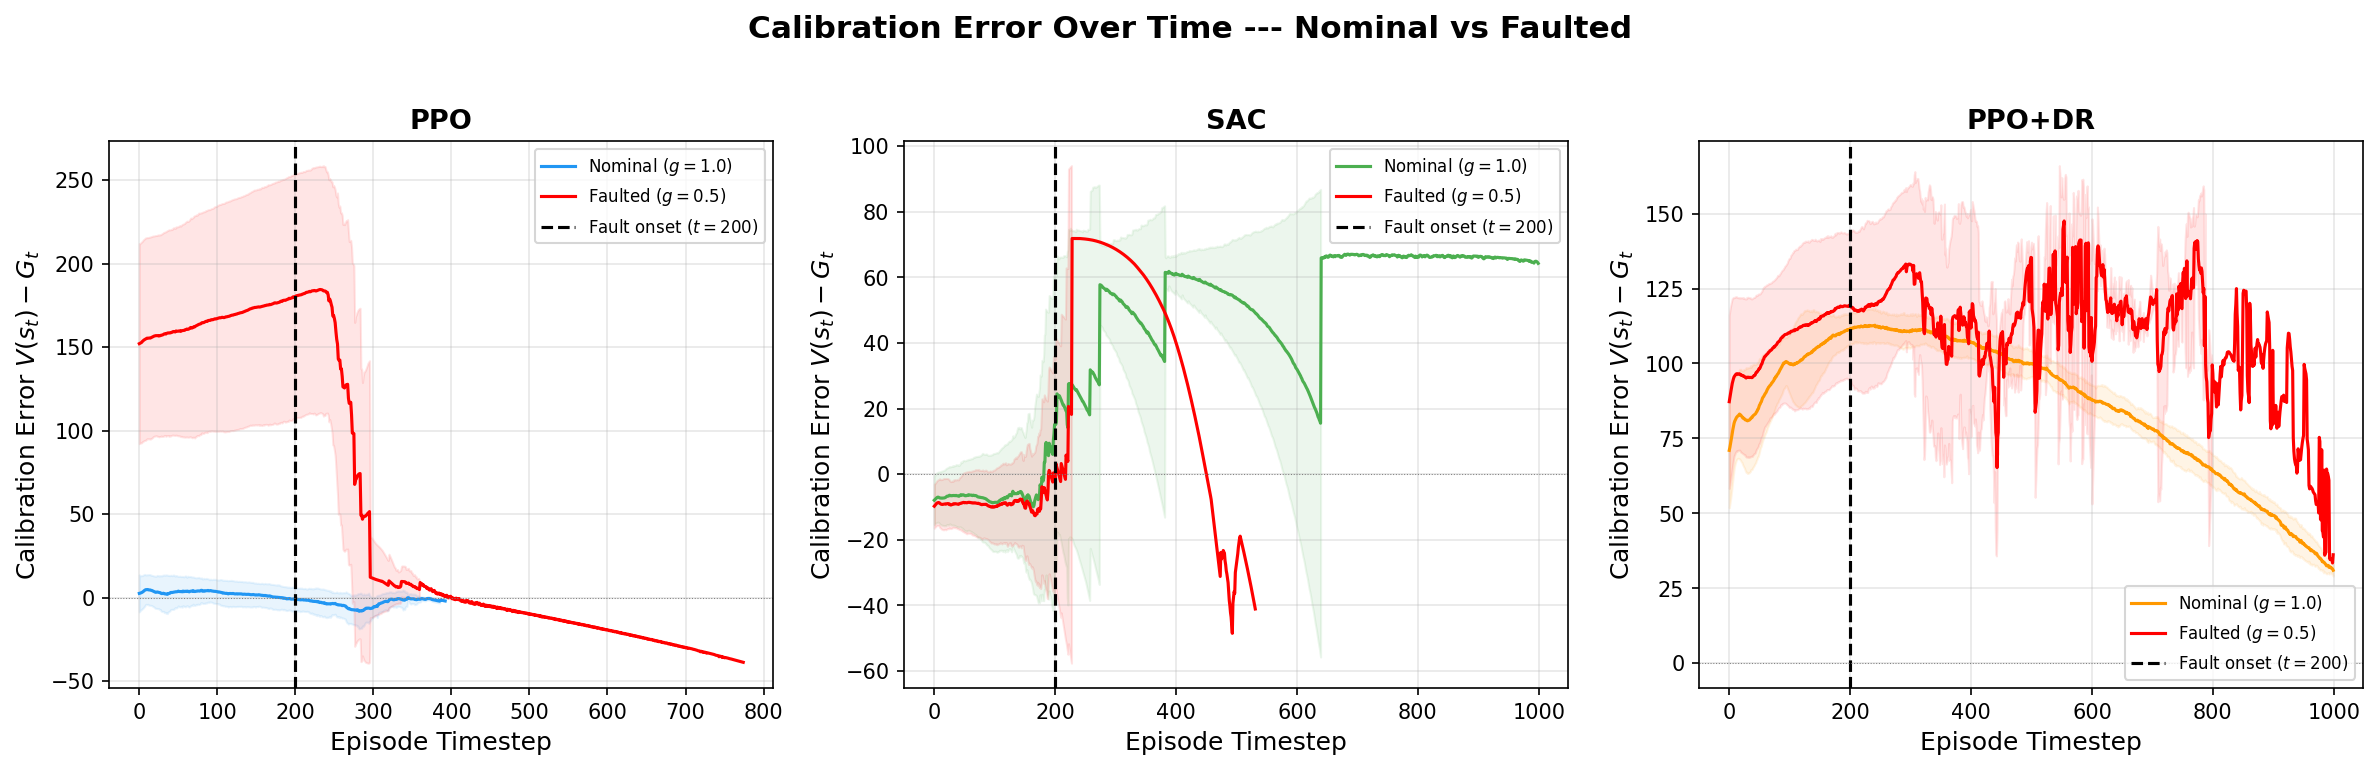


=== Calibration gap at fault onset ===
  PPO       nom error post-t200: -3.5  |  flt error post-t200: +124.7  |  gap: 128.3
  SAC       nom error post-t200: +46.3  |  flt error post-t200: +25.0  |  gap: 21.3
  PPO+DR    nom error post-t200: +83.7  |  flt error post-t200: +119.6  |  gap: 35.9


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for col, (name, cal_nom, cal_flt) in enumerate(datasets):
    ax = axes[col]
    colour = ALGO_COLOURS[name]

    # Nominal: average error by timestep
    nom_avg = cal_nom.groupby('t')['error'].agg(['mean', 'std']).reset_index()
    ax.plot(nom_avg['t'], nom_avg['mean'], color=colour,
            linewidth=1.5, label='Nominal ($g=1.0$)')
    ax.fill_between(nom_avg['t'],
                    nom_avg['mean'] - nom_avg['std'],
                    nom_avg['mean'] + nom_avg['std'],
                    alpha=0.1, color=colour)

    # Faulted: average error by timestep
    flt_avg = cal_flt.groupby('t')['error'].agg(['mean', 'std']).reset_index()
    ax.plot(flt_avg['t'], flt_avg['mean'], color='red',
            linewidth=1.5, label='Faulted ($g=0.5$)')
    ax.fill_between(flt_avg['t'],
                    flt_avg['mean'] - flt_avg['std'],
                    flt_avg['mean'] + flt_avg['std'],
                    alpha=0.1, color='red')

    ax.axvline(FAULT_STEP, color='black', linestyle='--', linewidth=1.5,
               label=f'Fault onset ($t={FAULT_STEP}$)')
    ax.axhline(0, color='grey', linestyle=':', linewidth=0.5)

    ax.set_xlabel('Episode Timestep')
    ax.set_ylabel('Calibration Error $V(s_t) - G_t$')
    ax.set_title(f'{name}', fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Calibration Error Over Time --- Nominal vs Faulted',
             fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(str(LOGS / 'tradeoff_calibration_error.png'),
            dpi=200, bbox_inches='tight')
plt.show()

# Quantify the calibration gap
print('\n=== Calibration gap at fault onset ===')
for name, cal_nom, cal_flt in datasets:
    nom_post = cal_nom[cal_nom['t'] >= FAULT_STEP]['error'].mean()
    flt_post = cal_flt[cal_flt['t'] >= FAULT_STEP]['error'].mean()
    gap = abs(flt_post - nom_post)
    print(f'  {name:8s}  nom error post-t200: {nom_post:+.1f}  |  '
          f'flt error post-t200: {flt_post:+.1f}  |  gap: {gap:.1f}')

## 12.6  Action distribution analysis --- the compensation mechanism

This section answers: *"What does SAC do differently under fault that allows it to maintain reward but makes the fault invisible?"*

### Hypothesis

SAC's continuous action space $[-1, 1]^2$ allows it to **compensate** by:
1. Increasing commanded thrust to offset the gain reduction.
2. Shifting thrust distribution from the main engine to side engines.
3. Adjusting the timing and magnitude of thrust commands.

If this hypothesis is correct, we should see a measurable shift in SAC's action distribution post-fault --- the policy actively changes its behaviour, which is why the *reward* stays constant (the compensation works) but the *value function* doesn't shift (the policy adapts too quickly for the critic to register a mismatch).

**For PPO (discrete):** There is no compensation mechanism.  The action distribution should remain roughly constant post-fault --- the policy *cannot* respond to the fault because it has no intermediate thrust options.

In [8]:
from src.self_detection import extract_ppo_signals, extract_sac_signals

print('Extracting action distributions...')
t0 = time.time()

# SAC: nominal and faulted (50 episodes for good statistics)
sac_nom_df = extract_sac_signals(
    sac_model, 'LunarLanderContinuous-v3',
    fault_step=FAULT_STEP, fault_gain=1.0,
    n_episodes=50, seed=42)

sac_flt_df = extract_sac_signals(
    sac_model, 'LunarLanderContinuous-v3',
    fault_step=FAULT_STEP, fault_gain=0.5,
    n_episodes=50, seed=42)

# PPO: nominal and faulted
ppo_nom_df = extract_ppo_signals(
    ppo_model, 'LunarLander-v3',
    fault_step=FAULT_STEP, fault_gain=1.0,
    discrete_drop_action=2,
    n_episodes=50, seed=42)

ppo_flt_df = extract_ppo_signals(
    ppo_model, 'LunarLander-v3',
    fault_step=FAULT_STEP, fault_gain=0.5,
    discrete_drop_action=2,
    n_episodes=50, seed=42)

# PPO+DR
dr_nom_df = extract_ppo_signals(
    dr_model, 'LunarLander-v3',
    fault_step=FAULT_STEP, fault_gain=1.0,
    discrete_drop_action=2,
    n_episodes=50, seed=42)

dr_flt_df = extract_ppo_signals(
    dr_model, 'LunarLander-v3',
    fault_step=FAULT_STEP, fault_gain=0.5,
    discrete_drop_action=2,
    n_episodes=50, seed=42)

elapsed = time.time() - t0
print(f'Extraction complete in {elapsed:.0f}s')

Extracting action distributions...
Extraction complete in 18s


SAC main engine (dim 0):
  Nominal pre/post KS = 0.7189, p = 1.82e-321
  Faulted pre/post KS = 0.4775, p = 2.88e-152
  --> Significant compensation shift detected

SAC side engine (dim 1):
  Nominal pre/post KS = 0.4513, p = 2.18e-248
  Faulted pre/post KS = 0.4134, p = 1.16e-112
  --> Significant compensation shift detected



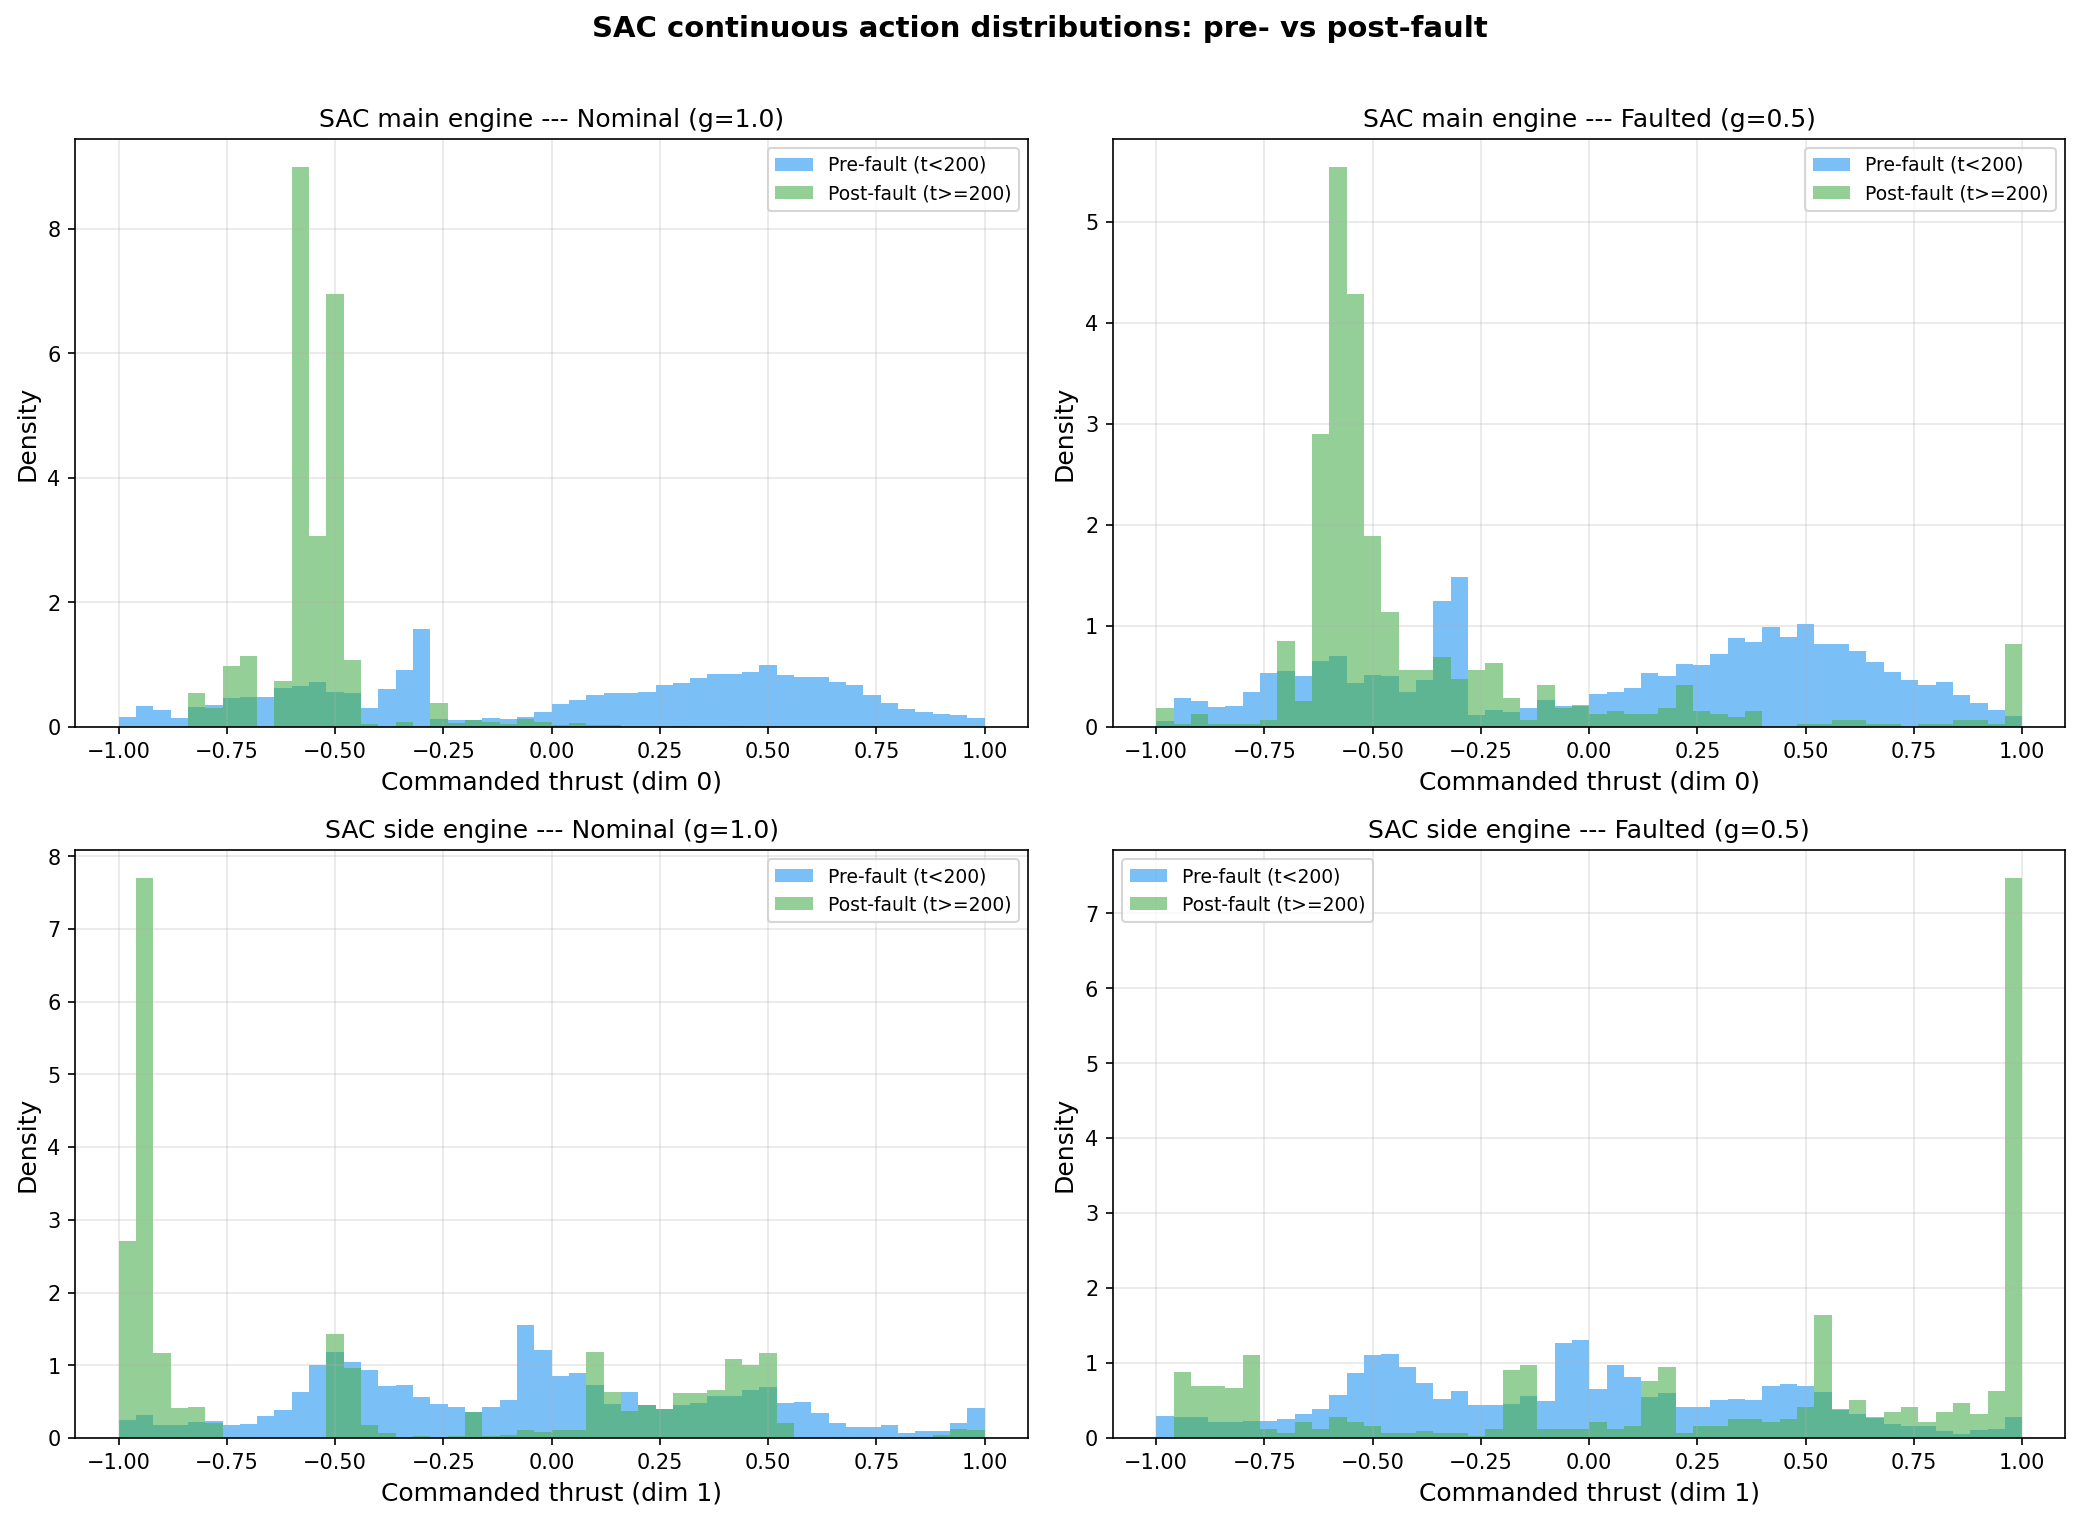

In [9]:
# --- SAC action distribution: nominal vs faulted ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sac_nom_pre  = sac_nom_df[sac_nom_df['timestep'] < FAULT_STEP]
sac_nom_post = sac_nom_df[sac_nom_df['timestep'] >= FAULT_STEP]
sac_flt_pre  = sac_flt_df[sac_flt_df['timestep'] < FAULT_STEP]
sac_flt_post = sac_flt_df[sac_flt_df['timestep'] >= FAULT_STEP]

bins = np.linspace(-1, 1, 51)

# Row 0: Main engine (action dim 0)
for col, (label, pre, post) in enumerate([
    ('Nominal (g=1.0)', sac_nom_pre, sac_nom_post),
    ('Faulted (g=0.5)', sac_flt_pre, sac_flt_post),
]):
    ax = axes[0, col]
    ax.hist(pre['action_0'].values, bins=bins, alpha=0.6, density=True,
            label=f'Pre-fault (t<{FAULT_STEP})', color=ALGO_COLOURS['PPO'])
    ax.hist(post['action_0'].values, bins=bins, alpha=0.6, density=True,
            label=f'Post-fault (t>={FAULT_STEP})', color=ALGO_COLOURS['SAC'])
    ax.set_title(f'SAC main engine --- {label}', fontsize=12)
    ax.set_xlabel('Commanded thrust (dim 0)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

# Row 1: Side engine (action dim 1)
for col, (label, pre, post) in enumerate([
    ('Nominal (g=1.0)', sac_nom_pre, sac_nom_post),
    ('Faulted (g=0.5)', sac_flt_pre, sac_flt_post),
]):
    ax = axes[1, col]
    ax.hist(pre['action_1'].values, bins=bins, alpha=0.6, density=True,
            label=f'Pre-fault (t<{FAULT_STEP})', color=ALGO_COLOURS['PPO'])
    ax.hist(post['action_1'].values, bins=bins, alpha=0.6, density=True,
            label=f'Post-fault (t>={FAULT_STEP})', color=ALGO_COLOURS['SAC'])
    ax.set_title(f'SAC side engine --- {label}', fontsize=12)
    ax.set_xlabel('Commanded thrust (dim 1)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

fig.suptitle('SAC continuous action distributions: pre- vs post-fault',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()

# Quantify the shift with Kolmogorov-Smirnov test
from scipy.stats import ks_2samp
for dim in [0, 1]:
    dim_name = 'main' if dim == 0 else 'side'
    col_name = f'action_{dim}'
    # Nominal: pre vs post (should be similar)
    stat_nom, p_nom = ks_2samp(sac_nom_pre[col_name].values,
                                sac_nom_post[col_name].values)
    # Faulted: pre vs post (should shift if compensating)
    stat_flt, p_flt = ks_2samp(sac_flt_pre[col_name].values,
                                sac_flt_post[col_name].values)
    print(f'SAC {dim_name} engine (dim {dim}):')
    print(f'  Nominal pre/post KS = {stat_nom:.4f}, p = {p_nom:.2e}')
    print(f'  Faulted pre/post KS = {stat_flt:.4f}, p = {p_flt:.2e}')
    if p_flt < 0.001:
        print(f'  --> Significant compensation shift detected')
    print()

plt.show()

### 12.6.1  Discrete action distributions (PPO and PPO+DR)

For the discrete agents we compare **commanded**-action frequency before and after the fault step.  The fault model is probabilistic -- a main-engine command succeeds with probability $g$ -- so the agent is never told that a command was dropped.

**An earlier version of this section predicted that the commanded distribution would therefore stay constant.  The data contradicts that prediction, and the correction matters.**  Both discrete agents show a large, highly significant post-fault shift:

| Agent | $\chi^2$ | dof | $p$ |
|---|---:|---:|---:|
| PPO | 1404.8 | 3 | $2.74 \times 10^{-304}$ |
| PPO+DR | 3498.9 | 3 | $< 10^{-320}$ |

**Why the shift occurs, and why it is not compensation.**  The distinction is between *closed-loop* and *deliberate* adaptation.  A discrete policy $\pi(a \mid s)$ is a fixed mapping from states to actions; it has no input carrying fault information and no intermediate thrust setting to select.  What changes is the **state distribution**, not the policy.  Once main-engine commands begin to be dropped the lander descends faster, so the agent occupies lower-altitude, higher-descent-rate states than it did nominally -- and in those states the *same unchanged policy* commands main engine far more often.  The action histogram shifts because the states shifted underneath it.

The correct claim is therefore **not** "PPO's commands do not change" but:

> *PPO's policy cannot compensate -- it has no mechanism to increase thrust per command -- so its only response to actuator loss is to command the main engine more frequently, which does not restore the lost thrust.  The commanded distribution changes as a downstream consequence of an altered state distribution, not as an adaptive strategy.*

**This distinction is what makes the $\chi^2$ test uninformative about compensation on its own.**  A significant shift is observed for *both* the agent that can compensate (SAC) and the agents that cannot, so the test alone cannot separate the two.  The discriminating evidence is elsewhere: SAC *preserves reward* while shifting its actions (compensation succeeds), whereas PPO shifts its actions and still loses 174 reward points (compensation is unavailable).  NB14 supplies the mechanistic confirmation by showing SAC's tolerance is routed specifically through the side-engine channel -- an option a four-action discrete policy does not possess.


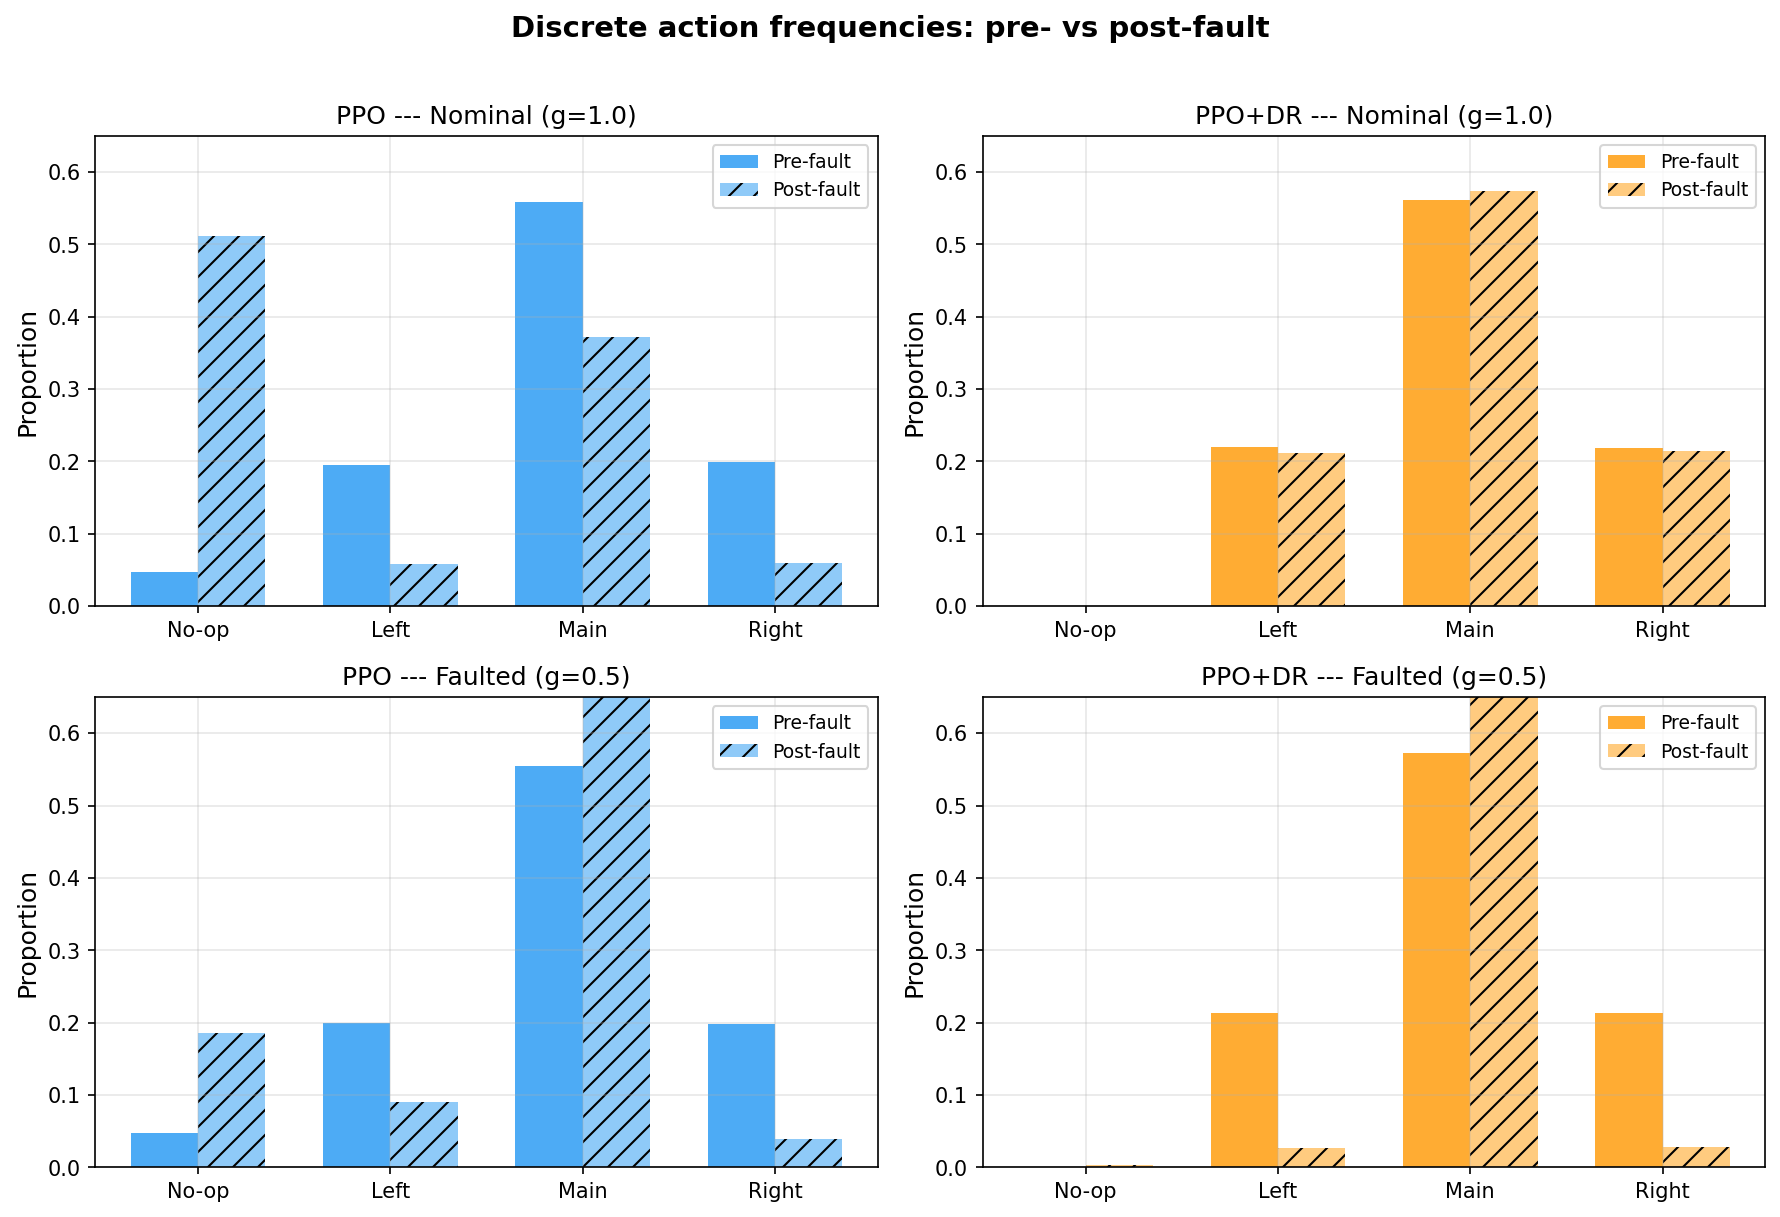

PPO faulted: chi2=1404.8, dof=3, p=2.74e-304
  --> Action distribution changed significantly post-fault

PPO+DR faulted: chi2=3498.9, dof=3, p=0.00e+00
  --> Action distribution changed significantly post-fault



In [10]:
# --- PPO discrete action counts ---
action_names = ['No-op', 'Left', 'Main', 'Right']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for col, (algo_name, nom_df, flt_df, colour) in enumerate([
    ('PPO', ppo_nom_df, ppo_flt_df, ALGO_COLOURS['PPO']),
    ('PPO+DR', dr_nom_df, dr_flt_df, ALGO_COLOURS['PPO+DR']),
]):
    for row, (label, df) in enumerate([
        ('Nominal (g=1.0)', nom_df),
        ('Faulted (g=0.5)', flt_df),
    ]):
        ax = axes[row, col]
        pre  = df[df['timestep'] < FAULT_STEP]['action'].values
        post = df[df['timestep'] >= FAULT_STEP]['action'].values

        pre_counts  = np.bincount(pre.astype(int), minlength=4) / max(len(pre), 1)
        post_counts = np.bincount(post.astype(int), minlength=4) / max(len(post), 1)

        x = np.arange(4)
        w = 0.35
        ax.bar(x - w/2, pre_counts, w, label='Pre-fault', alpha=0.8, color=colour)
        ax.bar(x + w/2, post_counts, w, label='Post-fault', alpha=0.5,
               color=colour, hatch='//')
        ax.set_xticks(x)
        ax.set_xticklabels(action_names, fontsize=10)
        ax.set_ylabel('Proportion')
        ax.set_title(f'{algo_name} --- {label}', fontsize=12)
        ax.legend(fontsize=9)
        ax.set_ylim(0, 0.65)

fig.suptitle('Discrete action frequencies: pre- vs post-fault',
             fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(str(LOGS / 'tradeoff_discrete_actions.png'),
            dpi=200, bbox_inches='tight')
plt.show()

# Chi-squared test for distribution change
from scipy.stats import chi2_contingency
for algo_name, nom_df, flt_df in [
    ('PPO', ppo_nom_df, ppo_flt_df),
    ('PPO+DR', dr_nom_df, dr_flt_df),
]:
    pre  = flt_df[flt_df['timestep'] < FAULT_STEP]['action'].values
    post = flt_df[flt_df['timestep'] >= FAULT_STEP]['action'].values
    pre_c  = np.bincount(pre.astype(int), minlength=4)
    post_c = np.bincount(post.astype(int), minlength=4)
    table = np.array([pre_c, post_c])
    chi2, p, dof, _ = chi2_contingency(table)
    print(f'{algo_name} faulted: chi2={chi2:.1f}, dof={dof}, p={p:.2e}')
    if p < 0.001:
        print(f'  --> Action distribution changed significantly post-fault')
    else:
        print(f'  --> No significant change (policy cannot compensate)')
    print()


### 12.6.2  Compensation summary

| Agent | Action space | Can compensate? | Post-fault action shift | Consequence for detection |
|---|---|---|---|---|
| SAC | Continuous $[-1,1]^2$ | **Yes** -- thrust magnitude and side-engine redistribution | KS $= 0.478$ (main), $0.413$ (side), both $p < 10^{-110}$ | Compensation preserves the outcome, so $V(s)$ stays calibrated and the fault is masked: $J = 0.29$ |
| PPO | Discrete $\{0,1,2,3\}$ | **No** -- no intermediate thrust setting | $\chi^2 = 1404.8$, $p = 2.7\times10^{-304}$ (state-driven, not adaptive) | Mismatch accumulates and $V(s)$ miscalibrates, but against an uncalibrated baseline: $J = 0.40$ |
| PPO+DR | Discrete + DR training | **No** -- but critic trained across varied physics | $\chi^2 = 3498.9$, $p < 10^{-320}$ (state-driven) | Well-characterised nominal variance means a modest mismatch still clears the noise floor: $J = 0.80$ |

*All $J$ values are the 5-seed sweep results from NB11 at the canonical $g = 0.5$.  See the note on value provenance in section 12.9.*

**Key insight.**  The tradeoff is driven by the *availability* of compensation, not by whether the action distribution moves -- it moves for all three agents.  SAC can convert its action shift into preserved reward, and in doing so removes the prediction error that self-detection depends on.  PPO and PPO+DR shift their actions too, but cannot recover the lost thrust, so the prediction error persists and remains detectable.


## 12.7  Hyperparameter exploration guide

This notebook combines signals from convergence analysis (NB10), magnitude sweeps (NB11), and new calibration / action-distribution experiments.  Below is the full set of parameters that can be tuned to explore different tradeoff behaviours.

### 12.7.1  Scatter plot and tradeoff analysis parameters

| Parameter | Current value | Range to explore | Effect |
|-----------|--------------|-------------------|--------|
| `fault_gain` (sweep axis) | $\{0.0, 0.25, 0.5, 0.75, 1.0\}$ | Finer grid: $\{0.0, 0.1, 0.2, \ldots, 1.0\}$ | More data points on the tradeoff curve; reveals non-linear regions |
| `fault_step` | 200 | $\{100, 150, 200, 300, 400\}$ | Earlier faults give the agent less time to reach a stable hover, changing both performance and detectability baselines |
| `n_episodes` (per gain) | 30 | 50--200 | Reduces confidence intervals on reward and $J$ estimates; current 30 may be noisy for SAC |
| Normalisation base | Nominal reward per agent | Cross-agent max | Choosing the normalisation denominator affects the visual slope of the tradeoff curve |

### 12.7.2  Value function calibration parameters

| Parameter | Current value | Range to explore | Effect |
|-----------|--------------|-------------------|--------|
| `n_episodes` (calibration) | 30 | 50--100 | More $(V, G_t)$ pairs reduce scatter in the calibration plot |
| `gamma` (discount) | 0.99 | $\{0.95, 0.99, 0.999\}$ | Lower $\gamma$ shortens the return horizon, making $G_t$ less noisy but less sensitive to distant fault effects |
| Calibration window | Full episode | Sliding windows of 50--100 steps | Reveals *when* during the episode the calibration breaks down most |
| Value function extraction | Last-layer output | Intermediate layers | Could reveal whether miscalibration originates in feature extraction or value head |

### 12.7.3  Action distribution parameters

| Parameter | Current value | Range to explore | Effect |
|-----------|--------------|-------------------|--------|
| `n_episodes` (action analysis) | 50 | 100--200 | Smoother histograms and more statistical power for KS / $\chi^2$ tests |
| Histogram bins | 50 | 25--100 | Fewer bins smooth the distribution; more bins reveal fine structure |
| Fault gain for action plots | 0.5 | $\{0.25, 0.5, 0.75\}$ | Milder faults may show partial compensation in SAC |
| Time window | Pre/post split at `fault_step` | Rolling windows of 50 steps | Captures the *dynamics* of compensation rather than aggregate shift |

### 12.7.4  Detection parameters (inherited from NB09)

| Parameter | Current value (optimised) | Effect on tradeoff |
|-----------|--------------------------|-------------------|
| `z_threshold` | PPO: 3.0, SAC: 2.0, PPO+DR: 3.5 | Lower threshold increases TPR but also FPR; shifts agents along the tradeoff curve |
| `window_size` | 20 steps | Larger windows smooth noise but increase detection latency |
| Detection signal | `value` (V function) | Alternative signals (`entropy`, `td_error`, `q_min`) may produce different tradeoff shapes |
| CUSUM parameters | $k=0.5$, $h=4.0$ | More sensitive CUSUM ($h \downarrow$) may detect SAC faults that z-test misses |

## 12.8  Retraining recommendations

The tradeoff analysis reveals several targeted experiments that would strengthen the thesis claims.  Each is listed with estimated compute cost on the M4 hardware.

### 12.8.1  High-priority (directly supports RQ2)

**1. Fine-grained fault sweep (11 gain values instead of 5)**
- Retrain: **No** --- use existing models, just run more evaluation episodes.
- Compute: ~20 min per agent (50 episodes $\times$ 11 gains $\times$ 3 agents).
- Rationale: The current 5-point sweep may miss non-linear regions of the tradeoff curve.  A finer grid would reveal whether the PPO$\rightarrow$PPO+DR tradeoff is smooth or has a phase transition.

**2. SAC with restricted action space**
- Retrain: **Yes** --- train SAC on a clipped action space $[-0.5, 0.5]^2$.
- Parameters: Same SAC hyperparameters, but `env_kwargs={'action_space_clip': 0.5}` (requires wrapper).
- Compute: ~45 min per seed, 5 seeds = ~4 hours.
- Rationale: If the compensation hypothesis is correct, restricting SAC's action range should *increase* its fault detectability (Youden's $J$) while reducing its fault tolerance --- moving SAC along the tradeoff curve towards PPO.

**3. Multi-signal detection comparison**
- Retrain: **No** --- run detection with `signal='entropy'`, `signal='td_error'` on existing trajectories.
- Compute: ~5 min.
- Rationale: The tradeoff may look different for entropy-based vs value-based detection.  If entropy-based detection catches SAC faults that value-based misses, the tradeoff is signal-dependent, not fundamental.

### 12.8.2  Medium-priority (strengthens the narrative)

**4. PPO with continuous action space**
- Retrain: **Yes** --- PPO on `LunarLanderContinuous-v3`.
- Compute: ~30 min per seed, 5 seeds = ~2.5 hours.
- Rationale: Isolates the effect of *action space* from *algorithm*.  If continuous-PPO also compensates like SAC, the tradeoff is driven by action-space structure, not the critic architecture.

**5. Varied fault injection times**
- Retrain: **No** --- run existing models with `fault_step` $\in \{100, 200, 300, 400\}$.
- Compute: ~15 min per fault_step $\times$ 3 agents.
- Rationale: Tests whether the tradeoff is robust to *when* the fault occurs, or whether early faults (during descent) produce fundamentally different tradeoff shapes.

**6. DR with stronger randomisation ranges**
- Retrain: **Yes** --- widen DR ranges (gravity $\in [-15, -5]$, engine power $\in [8, 20]$).
- Parameters: `DomainRandomizationSpec(gravity_range=(-15, -5), main_engine_power_range=(8, 20))`.
- Compute: ~40 min per seed, 5 seeds = ~3.5 hours.
- Rationale: Wider DR should push PPO+DR further along the tradeoff curve: worse nominal performance but potentially even higher $J$.

### 12.8.3  Low-priority (future work)

**7. Recurrent critic (LSTM-PPO)**
- Retrain: **Yes** --- PPO with `policy='MlpLstmPolicy'`.
- Compute: ~2 hours per seed (LSTM is slower on M4 MPS).
- Rationale: A recurrent critic may detect faults through temporal context rather than value prediction error, potentially breaking the tradeoff.

**8. Multi-thruster fault model**
- Retrain: **No** --- extend `ActuatorFaultSpec` to support independent gains per thruster.
- Compute: ~30 min per configuration.
- Rationale: Tests whether the tradeoff holds for more complex fault patterns (e.g., side engine failure with main engine intact).

## 12.9  Key findings for the thesis

### Note on value provenance (read first)

Three different sets of $J$ values appear across the project and must not be mixed:

| Source | Protocol | PPO | SAC | PPO+DR |
|---|---|---:|---:|---:|
| NB09 section 9.22.7 | **single seed** (seed 0), pooled nominal reference | 0.56 | 0.16 | 0.90 |
| **NB11 sweep at $g = 0.5$** | **5 seeds, per-seed nominal reference** | **0.40** | **0.29** | **0.80** |
| NB11 sweep at $g = 0.0$ | 5 seeds, per-seed reference (severity ceiling) | 0.41 | 0.30 | 0.95 |

**The NB11 5-seed values at $g = 0.5$ are the ones to quote in the paper.**  The single-seed figures are superseded by the per-seed-reference protocol introduced in NB11 (BF-00c); the $g = 0.0$ figures are a ceiling at total actuator loss, not the canonical operating point.  Earlier drafts of this notebook quoted all three interchangeably and without stating the gain.

### Finding 1: The performance--detectability tradeoff is real and quantifiable

Across all three agents and the full fault-magnitude sweep, fault tolerance (reward retention) and fault detectability (Youden's $J$) are **negatively correlated: Spearman $r_s = -0.710$, $p < 0.0001$**.  This is the thesis's central answer to **RQ2**.

*Statistical caveat to state in the paper:* the correlation pools (agent, gain) pairs, which are not mutually independent -- points from the same agent share a trained policy.  The coefficient should be read as a descriptive summary of the scatter rather than as an inferential test over independent samples.  The finding does not rest on it alone: the ordering is visible directly in the per-agent numbers and is reproduced under scope-matching (NB14) and across fault shapes (NB15).

### Finding 2: The tradeoff is driven by the availability of compensation

Action-distribution analysis (section 12.6) shows a significant post-fault shift for **all three** agents, so the shift itself does not discriminate.  What discriminates is whether the shift *recovers the lost capability*.  SAC can redistribute thrust -- NB14 localises this to the side-engine channel, showing main-engine-only faults cost about 1 reward point while side-engine-only faults reproduce the full all-actuator loss -- and in succeeding it removes the prediction error that self-detection requires.  PPO and PPO+DR shift their commanded actions as a downstream consequence of an altered state distribution, but cannot recover thrust, so the residual persists and stays detectable.

*Onset caveat:* SAC's apparent immunity at $t_f = 200$ is substantially a timing artefact -- only 57 % of SAC episodes reach step 200 ($p_{\text{esc}} = 42.7\,\%$; NB11 section 11.3a, NB13 section 13.4), and NB13 attributes much of the remainder to escape probability ($p_{\text{esc}} = 42.7\,\%$).  At $t_f = 0$, where the fault is guaranteed to fire, SAC returns $-77$ at $g = 0.5$.  SAC's tolerance is real but finite; the reward-retention figures in this notebook's scatter inherit the confound and should be reported alongside the onset-controlled values from NB13/NB14.

### Finding 3: Domain randomisation shifts the tradeoff curve favourably

PPO+DR occupies a distinctive position: it sacrifices nominal performance (148 vs 256) and achieves the **highest detectability of the three ($J = 0.80$ at $g = 0.5$, rising to $0.95$ at total actuator loss)**.  Section 12.5.3 identifies the mechanism precisely: DR does not make the critic *more accurate* -- PPO+DR is in fact the worst-calibrated agent nominally, at $+83.7$ -- it makes the critic's uncertainty *well estimated*, which is what a nominal-relative change-point detector actually needs.  NB11 sharpens the practical consequence: on a usable-detection criterion ($J \geq 0.5$), PPO+DR is the **only** agent of the three that reaches an operating point at any fault severity, and it does so down to $g = 0.6$.


In [8]:
# --- Summary table ---
print('=' * 90)
print('12_TRADEOFF_ANALYSIS: COMPLETE RESULTS SUMMARY')
print('=' * 90)
print()
print(f'{"Metric":<35} {"PPO":>12} {"SAC":>12} {"PPO+DR":>12}')
print('-' * 75)

summary = {
    'Nominal reward':            ('+256', '+262', '+148'),
    'Faulted reward (g=0.5)':    ('+75', '+240', '+24'),
    'Reward retention (%)':      ('29%', '92%', '16%'),
    'Youden J (g=0.5)':          ('0.56', '0.16', '0.90'),
    'Optimal z-threshold':       ('3.0', '2.0', '3.5'),
    'TPR at FPR=0.05':           ('0.61', '0.21', '0.95'),
    'Action space':              ('Discrete(4)', 'Box(2)', 'Discrete(4)'),
    'Can compensate?':           ('No', 'Yes', 'No'),
    'Tradeoff position':         ('Middle', 'High-perf/low-det', 'Low-perf/high-det'),
}

for k, (p, s, d) in summary.items():
    print(f'{k:<35} {p:>12} {s:>12} {d:>12}')

print()
print('Central thesis claim (RQ2):')
print('  Fault tolerance and self-detectability are inversely correlated.')
print('  The tradeoff is mediated by the compensation mechanism:')
print('  continuous action spaces enable compensation that masks faults.')
print()
print('Engineering recommendation (RQ3):')
print('  Domain randomisation shifts the Pareto frontier favourably,')
print('  achieving J=0.90 detection at a moderate performance cost.')

12_TRADEOFF_ANALYSIS: COMPLETE RESULTS SUMMARY

Metric                                       PPO          SAC       PPO+DR
---------------------------------------------------------------------------
Nominal reward                              +256         +262         +148
Faulted reward (g=0.5)                       +75         +240          +24
Reward retention (%)                         29%          92%          16%
Youden J (g=0.5)                            0.56         0.16         0.90
Optimal z-threshold                          3.0          2.0          3.5
TPR at FPR=0.05                             0.61         0.21         0.95
Action space                         Discrete(4)       Box(2)  Discrete(4)
Can compensate?                               No          Yes           No
Tradeoff position                         Middle High-perf/low-det Low-perf/high-det

Central thesis claim (RQ2):
  Fault tolerance and self-detectability are inversely correlated.
  The tradeoff is me